In [170]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

In [171]:
import numpy as np
import pandas as pd

np.random.seed(1)

sqft = np.linspace(500, 5000, 200)
price = 50*sqft + 0.03*(sqft**2) + np.random.normal(0, 30000, 200)

df = pd.DataFrame({
    "sqft_living": sqft,
    "price": price
})

df.to_csv("house_price_poly.csv", index=False)

In [172]:
df.head()

,sqft_living,price
0,500.000000,81230.360910
1,522.613065,15971.693338
2,545.226131,20334.299971
3,567.839196,5876.141709
4,590.452261,65943.858132


In [173]:
X=df['sqft_living'].to_numpy()
X=X.reshape(-1,1)
# Y=Y.reshape(-1,1)


In [174]:
X

array([[ 500.        ],
       [ 522.61306533],
       [ 545.22613065],
       [ 567.83919598],
       [ 590.45226131],
       [ 613.06532663],
       [ 635.67839196],
       [ 658.29145729],
       [ 680.90452261],
       [ 703.51758794],
       [ 726.13065327],
       [ 748.74371859],
       [ 771.35678392],
       [ 793.96984925],
       [ 816.58291457],
       [ 839.1959799 ],
       [ 861.80904523],
       [ 884.42211055],
       [ 907.03517588],
       [ 929.64824121],
       [ 952.26130653],
       [ 974.87437186],
       [ 997.48743719],
       [1020.10050251],
       [1042.71356784],
       [1065.32663317],
       [1087.93969849],
       [1110.55276382],
       [1133.16582915],
       [1155.77889447],
       [1178.3919598 ],
       [1201.00502513],
       [1223.61809045],
       [1246.23115578],
       [1268.84422111],
       [1291.45728643],
       [1314.07035176],
       [1336.68341709],
       [1359.29648241],
       [1381.90954774],
       [1404.52261307],
       [1427.135

In [175]:
Y=df['price'].to_numpy()

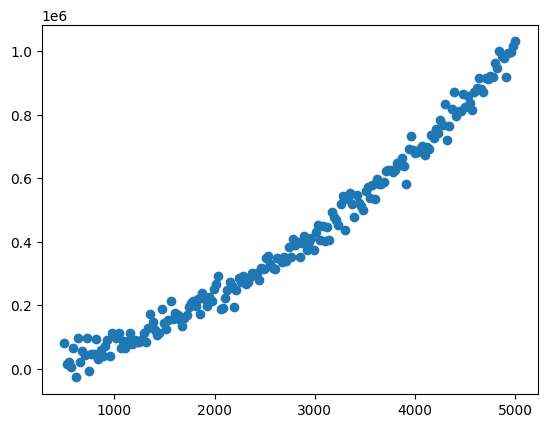

In [176]:
plt.scatter(X,Y)

In [177]:
from sklearn.linear_model import LinearRegression
model1=LinearRegression()
model1.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [178]:
pred1=model1.predict(X)


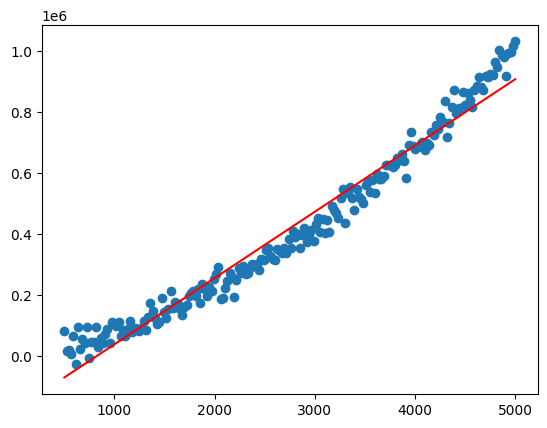

In [179]:
plt.scatter(X,Y)
plt.plot(X,pred1,c='r')

In [180]:
# X=np.c_[X,X**2]
# X

In [181]:
# model2=LinearRegression()
# model2.fit(X,Y)
# pred2=model2.predict(X)

In [182]:
# plt.scatter(X[:,0],Y)
# plt.plot(X[:,0],pred2,c='r')

In [183]:
### in we convert the data into train test split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size= 0.2,random_state= 42)

In [184]:
from sklearn.preprocessing import PolynomialFeatures
polyno=PolynomialFeatures(degree= 2)
X_poly_train=polyno.fit_transform(X_train)
X_poly_test=polyno.fit_transform(X_test)


In [185]:
print(X_poly_train.shape)
# (160, 6)

print(Y_train.shape)
# (40,)

(160, 3)
(160,)


In [186]:
print(X_train.shape) 
print(Y_train.shape)  
print(X_test.shape)   
print(Y_test.shape)   

(160, 1)
(160,)
(40, 1)
(40,)


In [187]:
print(X_poly_train.shape)
print(Y_train.shape)

(160, 3)
(160,)


In [188]:
model3=LinearRegression()
model3.fit(X_poly_train,Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
pred3=model3.predict(X_poly_train)


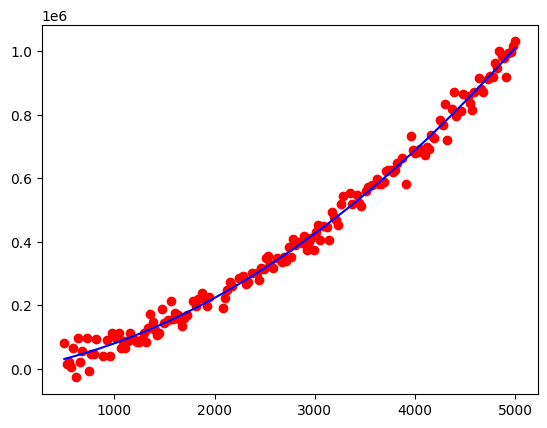

In [208]:
x=np.linspace(
    X_train[:,0].min(),
    X_train[:,0].max(),200
).reshape(-1,1)
x_poly=polyno.transform(x)
y=model3.predict(x_poly)
plt.scatter(X_train[:,0],Y_train,color='red')
plt.plot(X,y,color='blue')


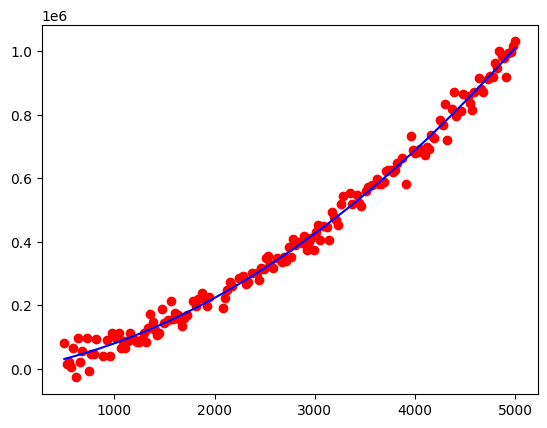

In [ ]:
# x_smooth = np.linspace(
#     X_train[:,0].min(),
#     X_train[:,0].max(),
#     200
# ).reshape(-1,1)

# x_smooth_poly = polyno.transform(x_smooth)
# y_smooth = model3.predict(x_smooth_poly)

# plt.scatter(X_train[:,0], Y_train, color="red")
# plt.plot(x_smooth, y_smooth, color="blue")
# plt.show()